# Data Preparation & Feature Engineering
## Airline Customer Satisfaction Dataset

This notebook transforms raw survey data into ML-ready features following the CRISP-DM "Prepare Data" phase.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'

SAT_PALETTE = {'satisfied': '#2ecc71', 'dissatisfied': '#e74c3c'}


CAT_COLS = ['Customer Type', 'Type of Travel', 'Class']
DELAY_COLS = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']

print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('airline.csv')
print(f'Raw dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Raw dataset: 129,880 rows x 22 columns


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


## 2. Data Quality Fixes
Address nulls and outliers identified during EDA.

In [3]:
print('=== Null Values ===')
null_summary = df.isnull().sum()
print(null_summary[null_summary > 0])
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

median_val = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'].fillna(median_val, inplace=True)
print(f"\nImputed {null_summary['Arrival Delay in Minutes']} nulls in 'Arrival Delay in Minutes' with median ({median_val})")
print(f'Nulls remaining: {df.isnull().sum().sum()}')

=== Null Values ===
Arrival Delay in Minutes    393
dtype: int64

Total nulls: 393

Imputed 393 nulls in 'Arrival Delay in Minutes' with median (0.0)
Nulls remaining: 0


In [4]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count:,}')
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'After removal: {df.shape}')
else:
    print('No duplicates found.')

Duplicate rows: 0
No duplicates found.


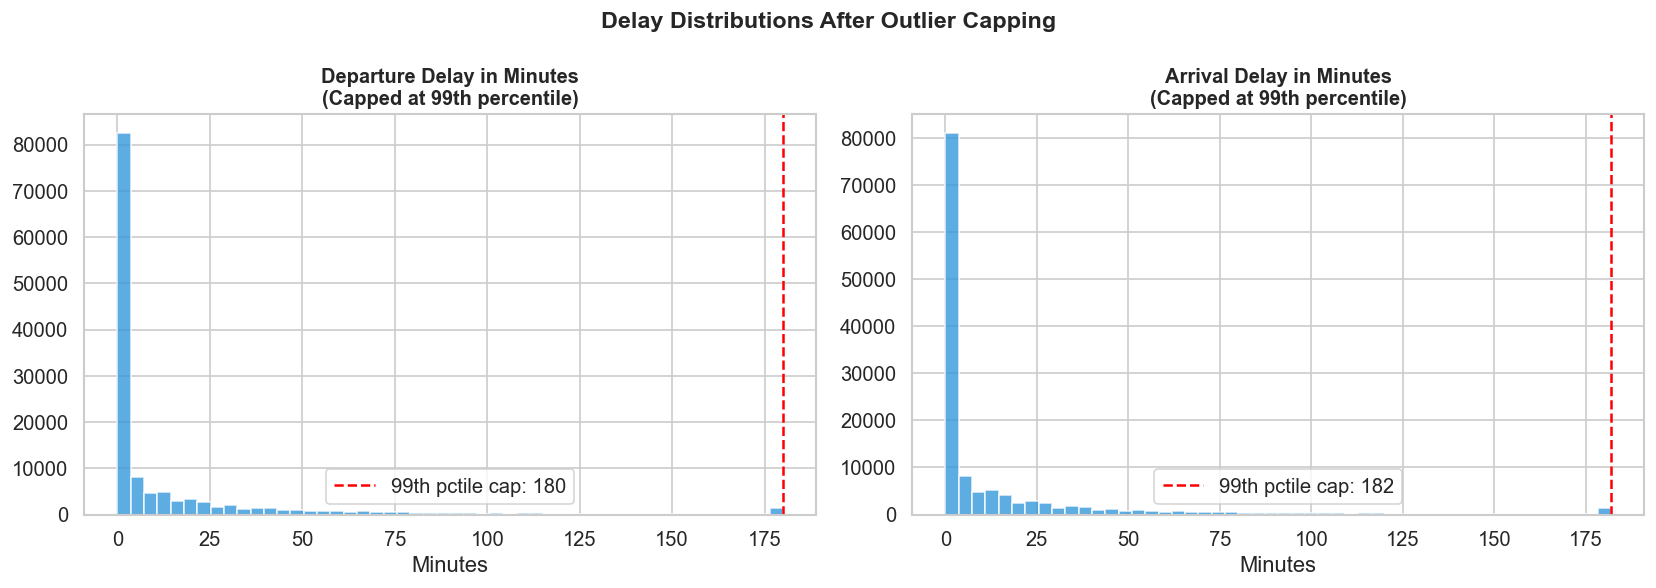

Delay stats after capping:
  Departure Delay in Minutes: max=180, mean=13.8, median=0.0
  Arrival Delay in Minutes: max=182, mean=14.2, median=0.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(DELAY_COLS):
    ax = axes[idx]
    p99 = df[col].quantile(0.99)

    df[col] = df[col].clip(upper=p99)

    ax.hist(df[col], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(p99, color='red', linestyle='--', label=f'99th pctile cap: {p99:.0f}')
    ax.set_title(f'{col}\n(Capped at 99th percentile)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Minutes')
    ax.legend()

plt.suptitle('Delay Distributions After Outlier Capping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Delay stats after capping:')
for col in DELAY_COLS:
    print(f'  {col}: max={df[col].max():.0f}, mean={df[col].mean():.1f}, median={df[col].median():.1f}')

In [6]:
quality_summary = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null': df.notnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Unique': df.nunique().values
})
print(f'Clean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Nulls: {df.isnull().sum().sum()} | Duplicates: {df.duplicated().sum()}')
quality_summary

Clean dataset: 129,880 rows x 22 columns
Nulls: 0 | Duplicates: 0


,Column,Dtype,Non-Null,Null %,Unique
0,satisfaction,object,129880,0.0,2
1,Customer Type,object,129880,0.0,2
2,Age,int64,129880,0.0,75
3,Type of Travel,object,129880,0.0,2
4,Class,object,129880,0.0,3
5,Flight Distance,int64,129880,0.0,5398
6,Seat comfort,int64,129880,0.0,6
7,Departure/Arrival time convenient,int64,129880,0.0,6
8,Food and drink,int64,129880,0.0,6
9,Gate location,int64,129880,0.0,6


## 3. Target Variable Encoding
Convert `satisfaction` from string to binary (1 = satisfied, 0 = dissatisfied).

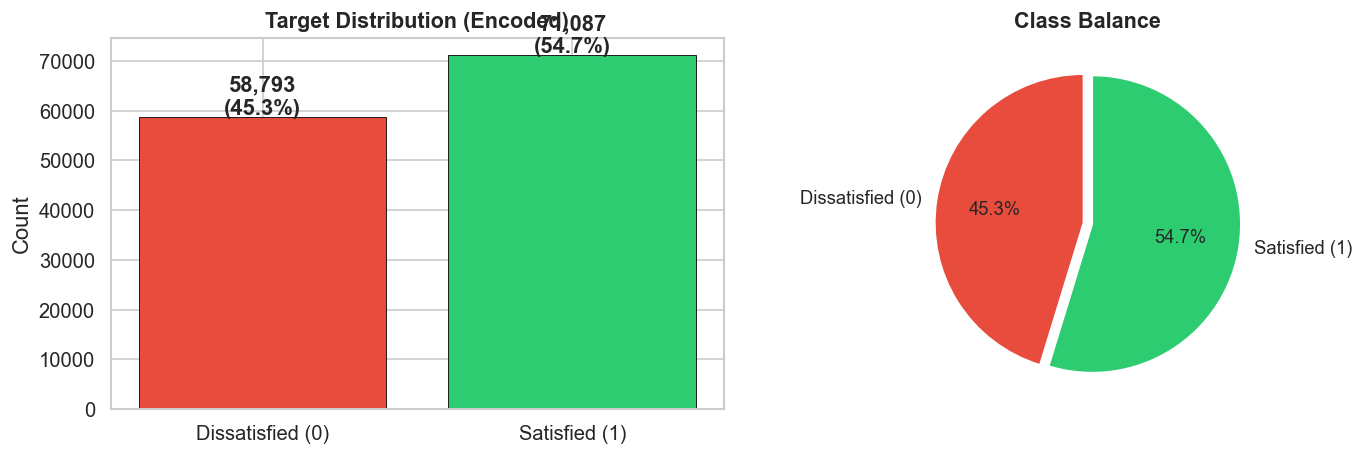

Class ratio (minority/majority): 0.827
Mild imbalance — stratified splitting recommended, SMOTE optional.


In [7]:
df['satisfaction_label'] = (df['satisfaction'] == 'satisfied').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['satisfaction_label'].value_counts().sort_index()
labels = ['Dissatisfied (0)', 'Satisfied (1)']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Target Distribution (Encoded)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, explode=(0.03, 0.03), textprops={'fontsize': 11})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

ratio = counts.min() / counts.max()
print(f'Class ratio (minority/majority): {ratio:.3f}')
print(f'Mild imbalance — stratified splitting recommended, SMOTE optional.')

## 4. Categorical Feature Encoding
Encode categorical variables for ML models.
- **Binary categoricals** → Label Encoding (0/1)
- **Class** → Ordinal Encoding (natural order: Eco < Eco Plus < Business)

In [8]:
print('Original categorical values:')
for col in CAT_COLS:
    print(f'  {col}: {df[col].unique().tolist()}')

Original categorical values:
  Customer Type: ['Loyal Customer', 'disloyal Customer']
  Type of Travel: ['Personal Travel', 'Business travel']
  Class: ['Eco', 'Business', 'Eco Plus']


In [9]:
df['Customer_Type_encoded'] = (df['Customer Type'] == 'Loyal Customer').astype(int)

df['Travel_Type_encoded'] = (df['Type of Travel'] == 'Business travel').astype(int)

class_map = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
df['Class_encoded'] = df['Class'].map(class_map)

print('Encoding mapping:')
print(f'  Customer Type: Loyal Customer -> 1, disloyal Customer -> 0')
print(f'  Type of Travel: Business travel -> 1, Personal Travel -> 0')
print(f'  Class: Eco -> 0, Eco Plus -> 1, Business -> 2 (ordinal)')

Encoding mapping:
  Customer Type: Loyal Customer -> 1, disloyal Customer -> 0
  Type of Travel: Business travel -> 1, Personal Travel -> 0
  Class: Eco -> 0, Eco Plus -> 1, Business -> 2 (ordinal)


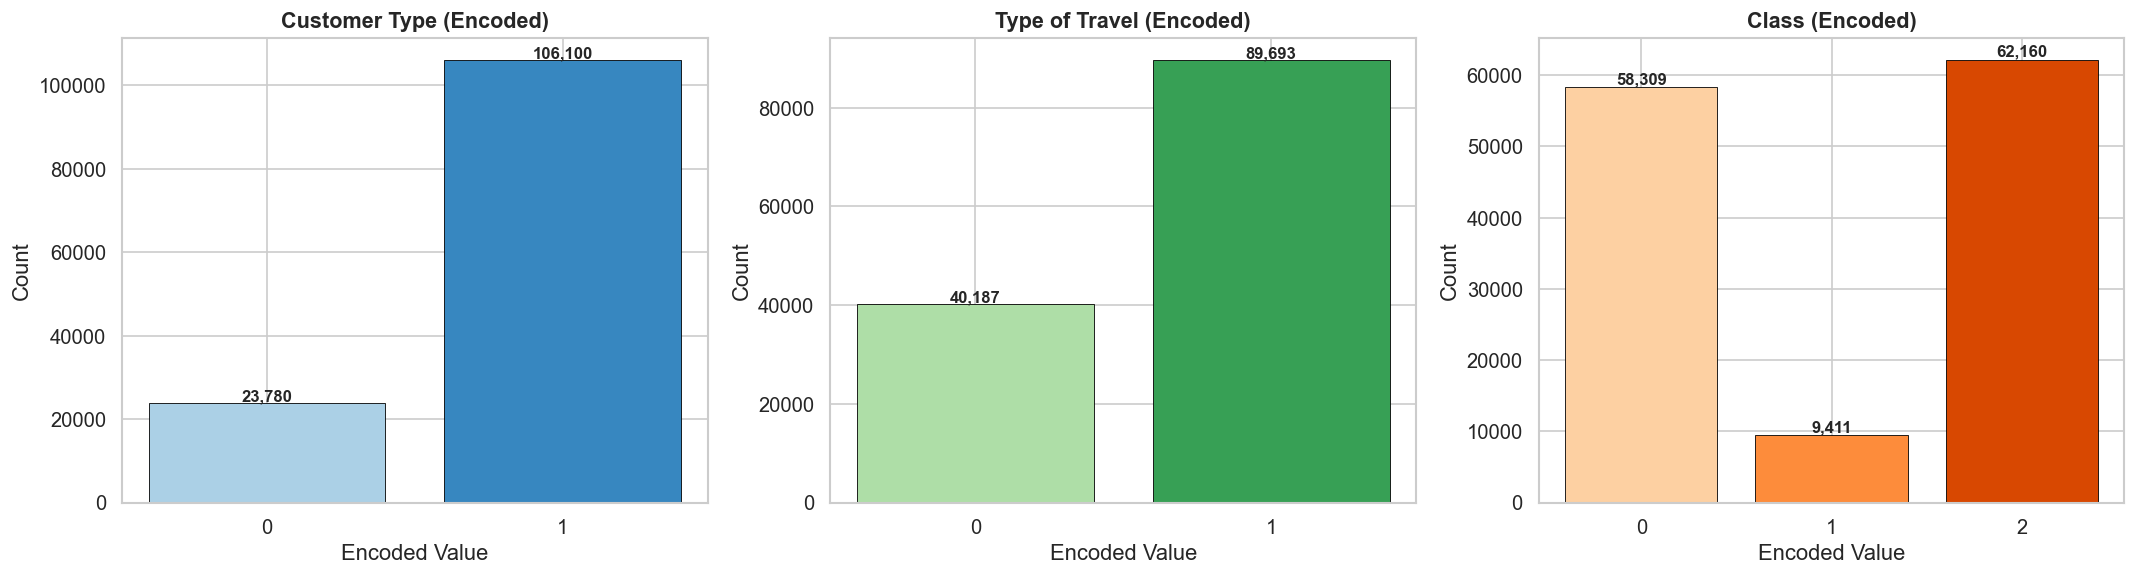

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

encoded_cols = ['Customer_Type_encoded', 'Travel_Type_encoded', 'Class_encoded']
titles = ['Customer Type', 'Type of Travel', 'Class']
palettes = ['Blues', 'Greens', 'Oranges']

for idx, (col, title, pal) in enumerate(zip(encoded_cols, titles, palettes)):
    ax = axes[idx]
    vc = df[col].value_counts().sort_index()
    bars = ax.bar(vc.index.astype(str), vc.values,
                  color=sns.color_palette(pal, n_colors=len(vc)),
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
                f'{val:,}', ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'{title} (Encoded)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Encoded Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [11]:
encoding_summary = pd.DataFrame({
    'Original Column': ['Customer Type', 'Customer Type',
                        'Type of Travel', 'Type of Travel',
                        'Class', 'Class', 'Class'],
    'Original Value': ['disloyal Customer', 'Loyal Customer',
                       'Personal Travel', 'Business travel',
                       'Eco', 'Eco Plus', 'Business'],
    'Encoded Value': [0, 1, 0, 1, 0, 1, 2],
    'Encoding Type': ['Binary', 'Binary', 'Binary', 'Binary',
                      'Ordinal', 'Ordinal', 'Ordinal']
})
encoding_summary.style.set_properties(**{'text-align': 'left'})

,Original Column,Original Value,Encoded Value,Encoding Type
0,Customer Type,disloyal Customer,0,Binary
1,Customer Type,Loyal Customer,1,Binary
2,Type of Travel,Personal Travel,0,Binary
3,Type of Travel,Business travel,1,Binary
4,Class,Eco,0,Ordinal
5,Class,Eco Plus,1,Ordinal
6,Class,Business,2,Ordinal


## 5. Feature Engineering
Create new features informed by EDA insights.

### 5.1 Service Rating Composite Scores
Aggregate 14 individual ratings into meaningful groups.

In [ ]:
SERVICE_COLS = [
    'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink',
    'Gate location', 'Inflight wifi service', 'Inflight entertainment',
    'Online support', 'Ease of Online booking', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service',
    'Cleanliness', 'Online boarding'
]
df['avg_service_rating'] = df[SERVICE_COLS].mean(axis=1)

ONLINE_COLS = ['Online boarding', 'Inflight wifi service', 'Online support', 'Ease of Online booking']
df['online_experience_score'] = df[ONLINE_COLS].mean(axis=1)

INFLIGHT_COLS = ['Seat comfort', 'Food and drink', 'Inflight entertainment',
                 'Leg room service', 'On-board service', 'Cleanliness']
df['inflight_experience_score'] = df[INFLIGHT_COLS].mean(axis=1)

GROUND_COLS = ['Gate location', 'Departure/Arrival time convenient',
               'Checkin service', 'Baggage handling']
df['ground_experience_score'] = df[GROUND_COLS].mean(axis=1)

composite_cols = ['avg_service_rating', 'online_experience_score',
                  'inflight_experience_score', 'ground_experience_score']

print('Composite Score Statistics:')
df[composite_cols].describe().round(2)

Composite Score Statistics:


,avg_service_rating,online_experience_score,inflight_experience_score,ground_experience_score
count,129880.00,129880.00,129880.00,129880.00
mean,3.31,3.40,3.29,3.25
std,0.67,1.11,0.81,0.80
min,1.07,0.50,0.50,0.75
25%,2.86,2.75,2.67,2.75
50%,3.36,3.75,3.33,3.25
75%,3.79,4.00,3.83,3.75
max,5.00,5.00,5.00,5.00


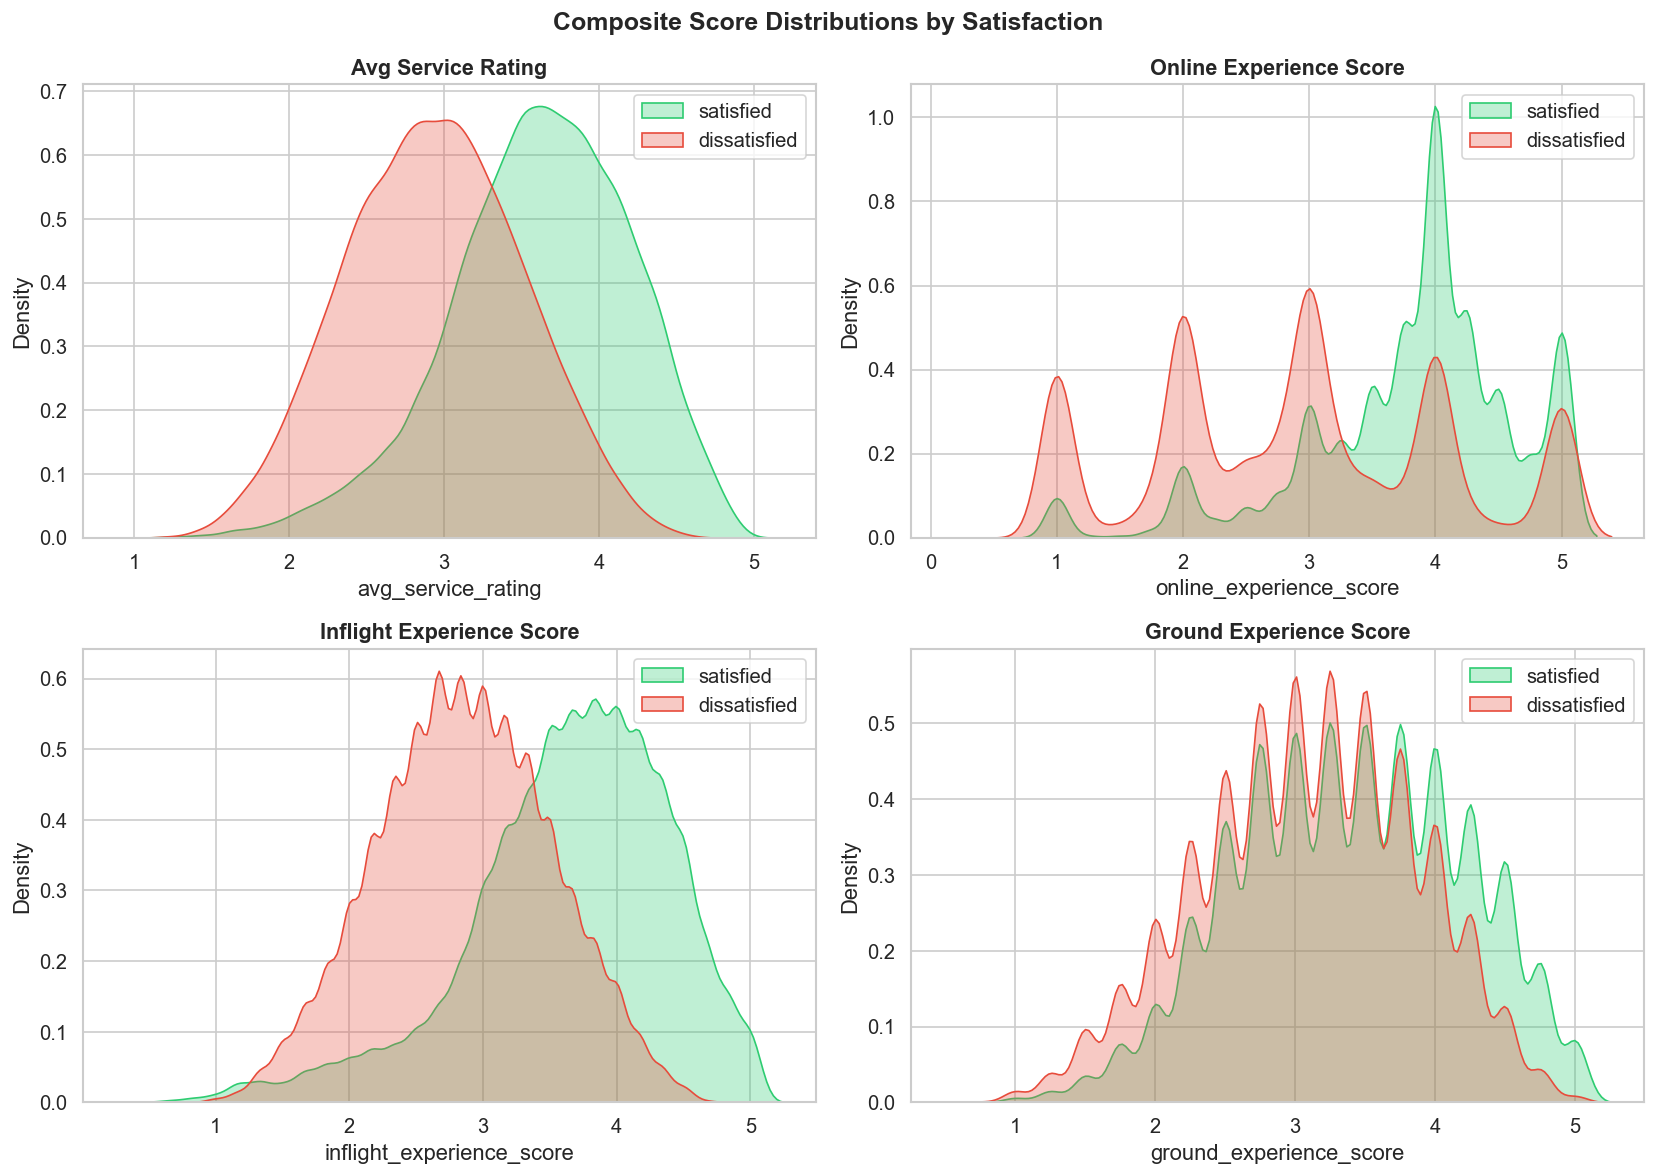

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(composite_cols):
    ax = axes[idx // 2][idx % 2]
    for label, color in SAT_PALETTE.items():
        subset = df[df['satisfaction'] == label][col]
        sns.kdeplot(subset, color=color, label=label, fill=True, alpha=0.3, ax=ax)
    ax.set_title(f'{col.replace("_", " ").title()}', fontsize=13, fontweight='bold')
    ax.legend()

plt.suptitle('Composite Score Distributions by Satisfaction', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Binned Features
Create categorical bins for Age and Flight Distance.

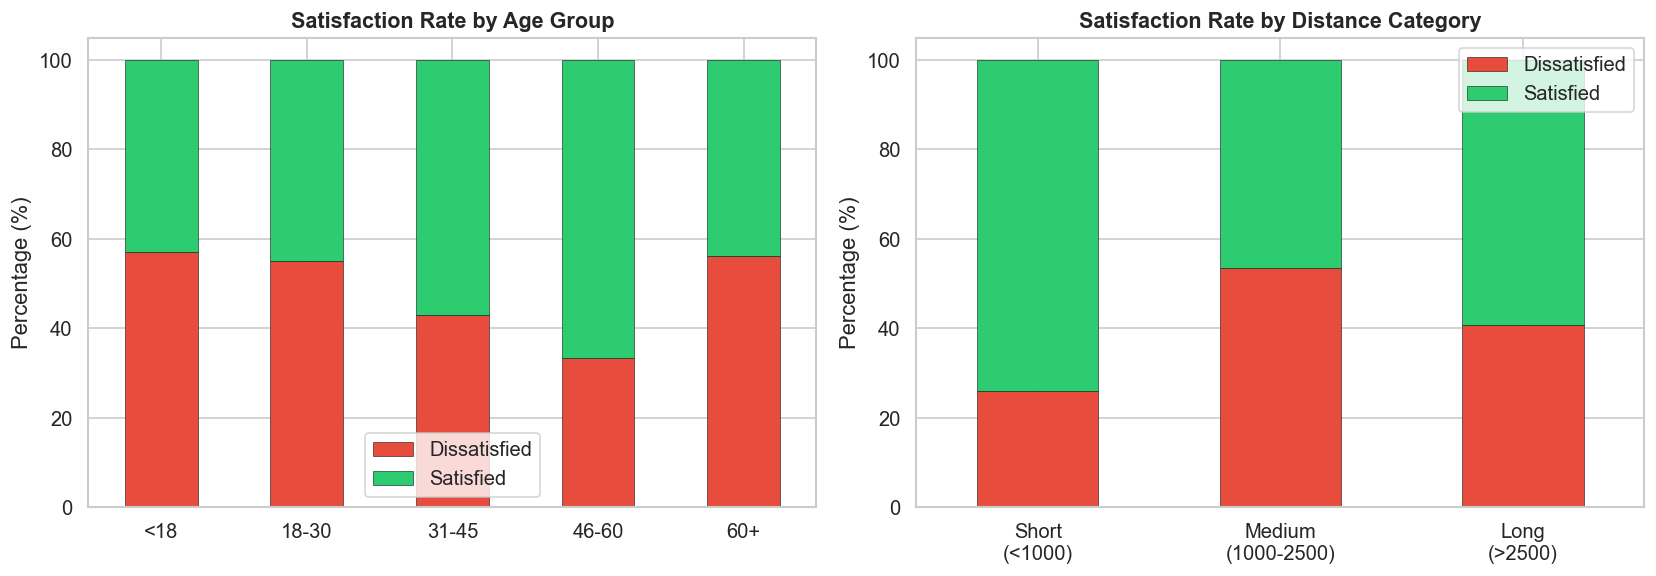

Age Group mapping: 0=<18, 1=18-30, 2=31-45, 3=46-60, 4=60+
Distance Category mapping: 0=Short(<1000), 1=Medium(1000-2500), 2=Long(>2500)


In [14]:
bins_age = [0, 18, 30, 45, 60, 100]
labels_age = [0, 1, 2, 3, 4]
df['Age_Group'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age).astype(int)

bins_dist = [0, 1000, 2500, 7000]
labels_dist = [0, 1, 2]
df['Distance_Category'] = pd.cut(df['Flight Distance'], bins=bins_dist, labels=labels_dist).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_labels = ['<18', '18-30', '31-45', '46-60', '60+']
ax1 = axes[0]
ct = pd.crosstab(df['Age_Group'], df['satisfaction_label'], normalize='index') * 100
ct.index = age_labels
ct.plot(kind='bar', stacked=True, ax=ax1, color=['#e74c3c', '#2ecc71'],
        edgecolor='black', linewidth=0.3)
ax1.set_title('Satisfaction Rate by Age Group', fontsize=13, fontweight='bold')
ax1.set_xticklabels(age_labels, rotation=0)
ax1.set_ylabel('Percentage (%)')
ax1.legend(['Dissatisfied', 'Satisfied'], title='')

dist_labels = ['Short\n(<1000)', 'Medium\n(1000-2500)', 'Long\n(>2500)']
ax2 = axes[1]
ct2 = pd.crosstab(df['Distance_Category'], df['satisfaction_label'], normalize='index') * 100
ct2.index = dist_labels
ct2.plot(kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#2ecc71'],
         edgecolor='black', linewidth=0.3)
ax2.set_title('Satisfaction Rate by Distance Category', fontsize=13, fontweight='bold')
ax2.set_xticklabels(dist_labels, rotation=0)
ax2.set_ylabel('Percentage (%)')
ax2.legend(['Dissatisfied', 'Satisfied'], title='')

plt.tight_layout()
plt.show()

print('Age Group mapping: 0=<18, 1=18-30, 2=31-45, 3=46-60, 4=60+')
print('Distance Category mapping: 0=Short(<1000), 1=Medium(1000-2500), 2=Long(>2500)')

### 5.3 Delay-Derived Features
Engineer features from the delay columns.

In [15]:
df['total_delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']

df['has_delay'] = (df['total_delay'] > 0).astype(int)

df['delay_ratio'] = df['Arrival Delay in Minutes'] / (df['Departure Delay in Minutes'] + 1)

delay_features = ['total_delay', 'has_delay', 'delay_ratio']

print('Delay Feature Statistics:')
print(df[delay_features].describe().round(2))
print(f"\nPassengers with any delay: {df['has_delay'].sum():,} ({df['has_delay'].mean()*100:.1f}%)")
print(f"Passengers with zero delay: {(df['has_delay']==0).sum():,} ({(df['has_delay']==0).mean()*100:.1f}%)")

Delay Feature Statistics:
       total_delay  has_delay  delay_ratio
count    129880.00  129880.00    129880.00
mean         28.02       0.54         1.45
std          61.25       0.50         4.67
min           0.00       0.00         0.00
25%           0.00       0.00         0.00
50%           2.00       1.00         0.00
75%          24.00       1.00         0.97
max         362.00       1.00       141.00

Passengers with any delay: 70,382 (54.2%)
Passengers with zero delay: 59,498 (45.8%)


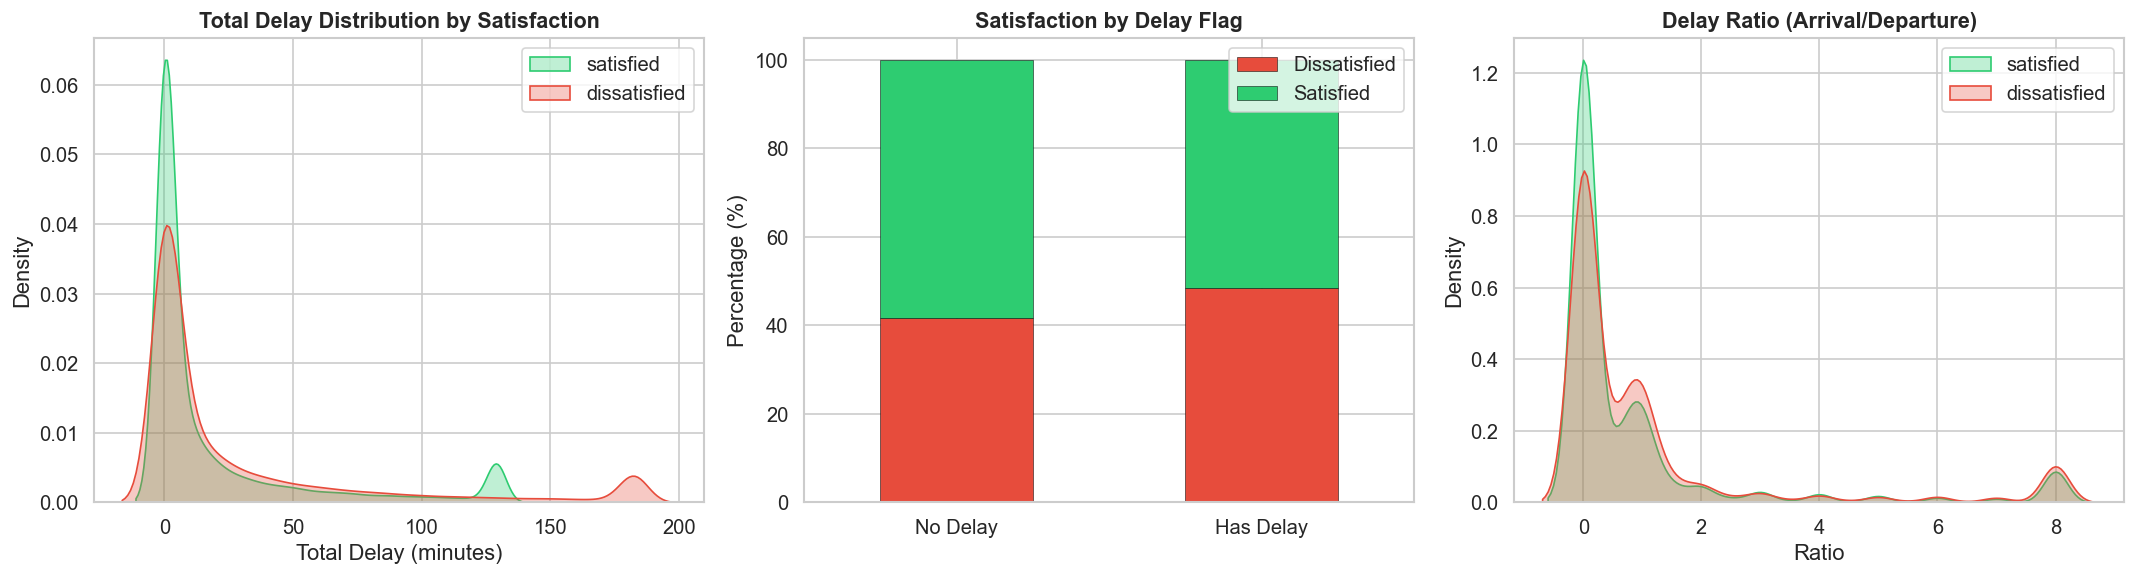

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
for label, color in SAT_PALETTE.items():
    subset = df[df['satisfaction'] == label]['total_delay']
    subset_clipped = subset.clip(upper=subset.quantile(0.95))
    sns.kdeplot(subset_clipped, color=color, label=label, fill=True, alpha=0.3, ax=ax1)
ax1.set_title('Total Delay Distribution by Satisfaction', fontsize=13, fontweight='bold')
ax1.set_xlabel('Total Delay (minutes)')
ax1.legend()

ax2 = axes[1]
ct = pd.crosstab(df['has_delay'], df['satisfaction_label'], normalize='index') * 100
ct.index = ['No Delay', 'Has Delay']
ct.plot(kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#2ecc71'],
        edgecolor='black', linewidth=0.3)
ax2.set_title('Satisfaction by Delay Flag', fontsize=13, fontweight='bold')
ax2.set_xticklabels(['No Delay', 'Has Delay'], rotation=0)
ax2.set_ylabel('Percentage (%)')
ax2.legend(['Dissatisfied', 'Satisfied'], title='')

ax3 = axes[2]
ratio_clipped = df['delay_ratio'].clip(upper=df['delay_ratio'].quantile(0.95))
for label, color in SAT_PALETTE.items():
    subset = ratio_clipped[df['satisfaction'] == label]
    sns.kdeplot(subset, color=color, label=label, fill=True, alpha=0.3, ax=ax3)
ax3.set_title('Delay Ratio (Arrival/Departure)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Ratio')
ax3.legend()

plt.tight_layout()
plt.show()

### 5.4 Interaction Features
Capture combined effects of categorical variables.

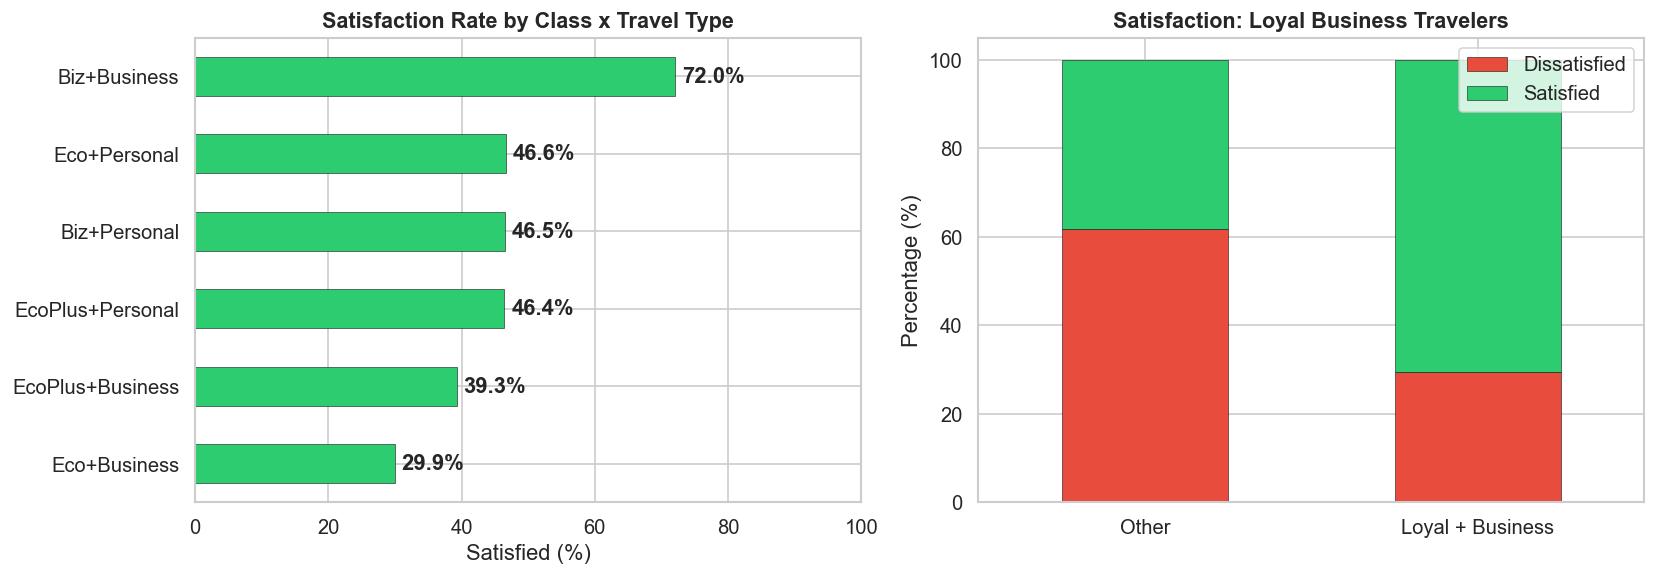

Interaction feature mapping: {'0_0': 0, '0_1': 1, '1_0': 2, '1_1': 3, '2_0': 4, '2_1': 5}


In [ ]:
# df['class_travel_interaction'] = df['Class_encoded'].astype(str) + '_' + df['Travel_Type_encoded'].astype(str)
# interaction_map = {val: idx for idx, val in enumerate(sorted(df['class_travel_interaction'].unique()))}
# df['class_travel_interaction'] = df['class_travel_interaction'].map(interaction_map)

# df['loyal_business'] = (df['Customer_Type_encoded'] & df['Travel_Type_encoded']).astype(int)

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ax1 = axes[0]
# ct = pd.crosstab(df['class_travel_interaction'], df['satisfaction_label'], normalize='index') * 100
# interaction_labels = ['Eco+Personal', 'Eco+Business', 'EcoPlus+Personal',
#                       'EcoPlus+Business', 'Biz+Personal', 'Biz+Business']
# ct.index = interaction_labels
# ct[[1]].sort_values(1).plot(kind='barh', ax=ax1, color='#2ecc71',
#                             edgecolor='black', linewidth=0.3, legend=False)
# ax1.set_title('Satisfaction Rate by Class x Travel Type', fontsize=13, fontweight='bold')
# ax1.set_xlabel('Satisfied (%)')
# ax1.set_xlim(0, 100)
# for i, v in enumerate(ct[1].sort_values().values):
#     ax1.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

# ax2 = axes[1]
# ct2 = pd.crosstab(df['loyal_business'], df['satisfaction_label'], normalize='index') * 100
# ct2.index = ['Other', 'Loyal + Business']
# ct2.plot(kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#2ecc71'],
#          edgecolor='black', linewidth=0.3)
# ax2.set_title('Satisfaction: Loyal Business Travelers', fontsize=13, fontweight='bold')
# ax2.set_xticklabels(['Other', 'Loyal + Business'], rotation=0)
# ax2.set_ylabel('Percentage (%)')
# ax2.legend(['Dissatisfied', 'Satisfied'], title='')

# plt.tight_layout()
# plt.show()

# print(f"Interaction feature mapping: {interaction_map}")

## 6. Numerical Scaling
Apply standardization and normalization for ML readiness.
- **Z-score (StandardScaler)**: Age, Flight Distance, delay features
- **Min-Max (0-1)**: Service ratings

In [18]:
continuous_to_scale = ['Age', 'Flight Distance', 'total_delay', 'delay_ratio']
scaler_std = StandardScaler()

df_scaled = df.copy()
df_scaled[continuous_to_scale] = scaler_std.fit_transform(df[continuous_to_scale])

print('Z-score Standardization Applied:')
print(df_scaled[continuous_to_scale].describe().round(3))

Z-score Standardization Applied:
              Age  Flight Distance  total_delay  delay_ratio
count  129880.000       129880.000   129880.000   129880.000
mean       -0.000            0.000       -0.000        0.000
std         1.000            1.000        1.000        1.000
min        -2.145           -1.880       -0.457       -0.310
25%        -0.822           -0.606       -0.457       -0.310
50%         0.038           -0.055       -0.425       -0.310
75%         0.765            0.548       -0.066       -0.102
max         3.014            4.838        5.453       29.905


In [19]:
scaler_mm = MinMaxScaler()
df_scaled[SERVICE_COLS] = scaler_mm.fit_transform(df[SERVICE_COLS])

print('Min-Max Scaling Applied to Service Ratings:')
print(df_scaled[SERVICE_COLS].describe().round(3))

Min-Max Scaling Applied to Service Ratings:
       Seat comfort  Departure/Arrival time convenient  Food and drink  \
count    129880.000                         129880.000      129880.000   
mean          0.568                              0.598           0.570   
std           0.279                              0.305           0.289   
min           0.000                              0.000           0.000   
25%           0.400                              0.400           0.400   
50%           0.600                              0.600           0.600   
75%           0.800                              0.800           0.800   
max           1.000                              1.000           1.000   

       Gate location  Inflight wifi service  Inflight entertainment  \
count     129880.000             129880.000              129880.000   
mean           0.598                  0.650                   0.677   
std            0.261                  0.264                   0.269   
min  

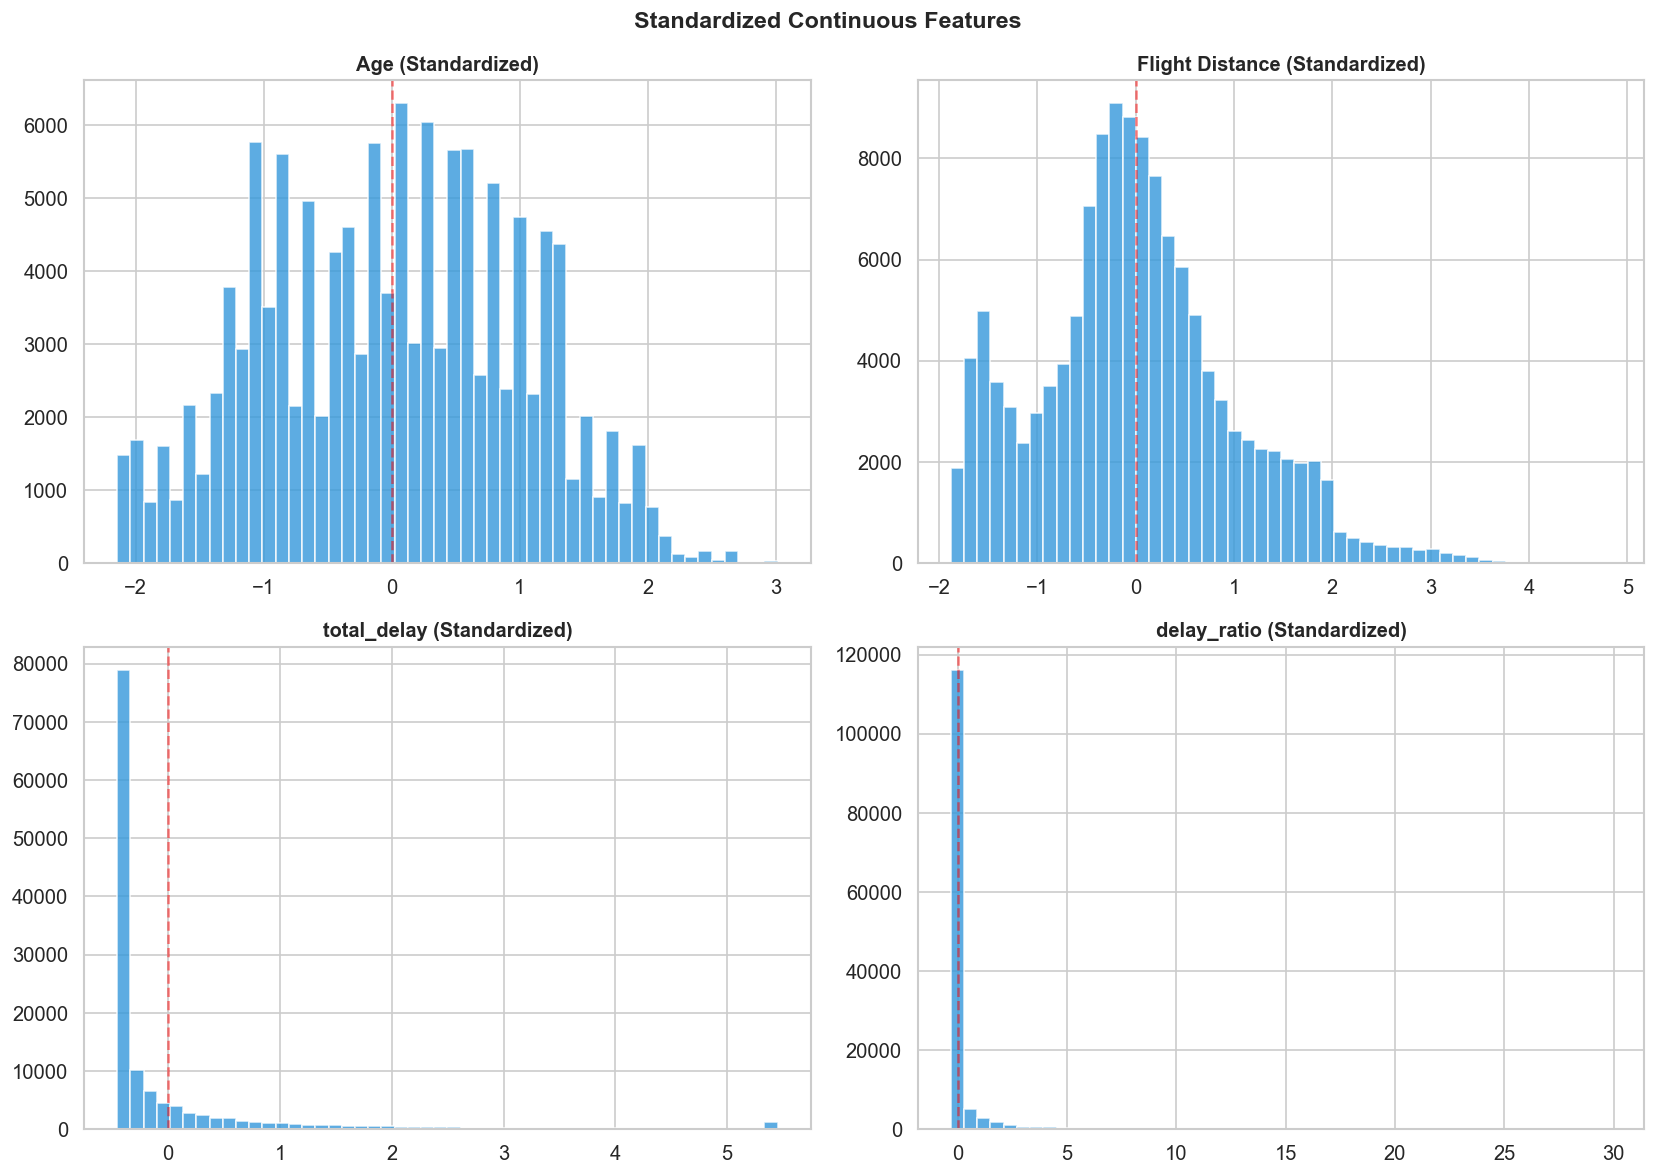

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(['Age', 'Flight Distance', 'total_delay', 'delay_ratio']):
    ax = axes[idx // 2][idx % 2]
    ax.hist(df_scaled[col], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col} (Standardized)', fontsize=12, fontweight='bold')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Standardized Continuous Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Selection & Correlation Analysis
Evaluate all features (original + engineered) against the target.

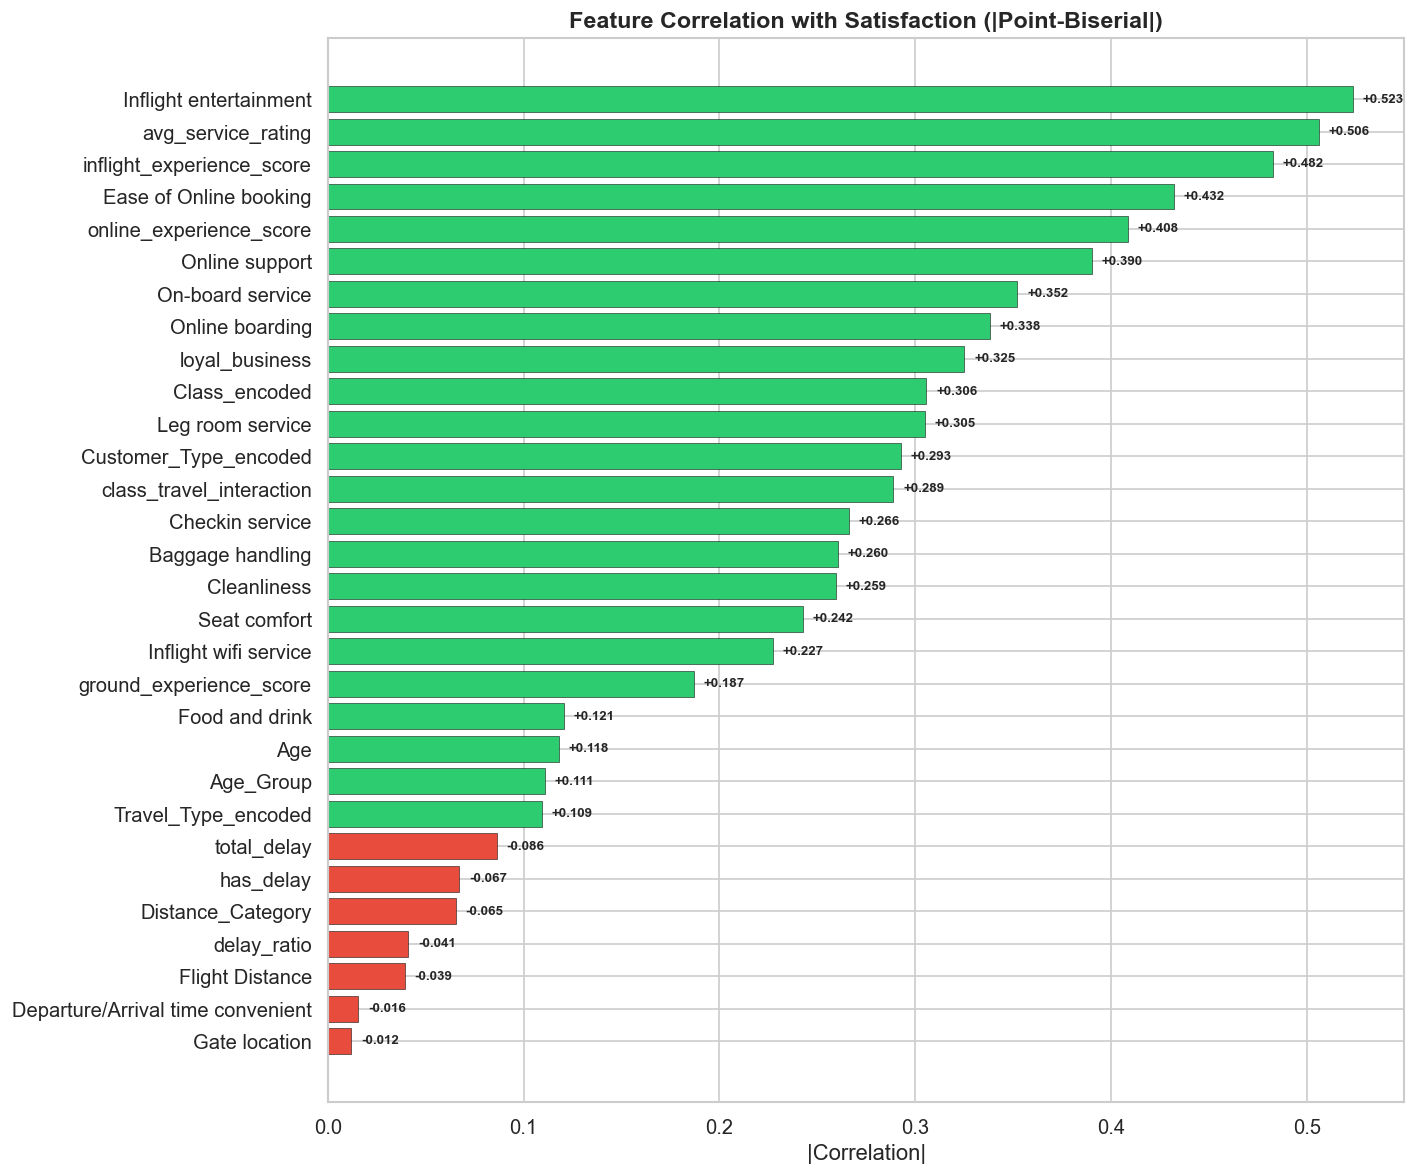

Top 10 features by correlation:


,correlation,direction,p_value
Inflight entertainment,0.523496,+,0.0
avg_service_rating,0.506039,+,0.0
inflight_experience_score,0.482336,+,0.0
Ease of Online booking,0.431772,+,0.0
online_experience_score,0.408336,+,0.0
Online support,0.390143,+,0.0
On-board service,0.352047,+,0.0
Online boarding,0.338147,+,0.0
loyal_business,0.324947,+,0.0
Class_encoded,0.305535,+,0.0


In [21]:
feature_cols = (SERVICE_COLS +
    ['Age', 'Flight Distance',
     'Customer_Type_encoded', 'Travel_Type_encoded', 'Class_encoded',
     'avg_service_rating', 'online_experience_score',
     'inflight_experience_score', 'ground_experience_score',
     'Age_Group', 'Distance_Category',
     'total_delay', 'has_delay', 'delay_ratio',
     'class_travel_interaction', 'loyal_business'])

correlations = {}
for col in feature_cols:
    corr_val, pval = stats.pointbiserialr(df['satisfaction_label'], df[col])
    correlations[col] = {'correlation': abs(corr_val), 'direction': '+' if corr_val > 0 else '-', 'p_value': pval}

corr_df = pd.DataFrame(correlations).T.sort_values('correlation', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#2ecc71' if d == '+' else '#e74c3c' for d in corr_df['direction']]
bars = ax.barh(corr_df.index[::-1], corr_df['correlation'][::-1].astype(float),
               color=colors[::-1], edgecolor='black', linewidth=0.3)
ax.set_title('Feature Correlation with Satisfaction (|Point-Biserial|)', fontsize=14, fontweight='bold')
ax.set_xlabel('|Correlation|')

for bar, val, d in zip(bars, corr_df['correlation'][::-1].astype(float), corr_df['direction'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{d}{val:.3f}',
            va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print('Top 10 features by correlation:')
corr_df.head(10)

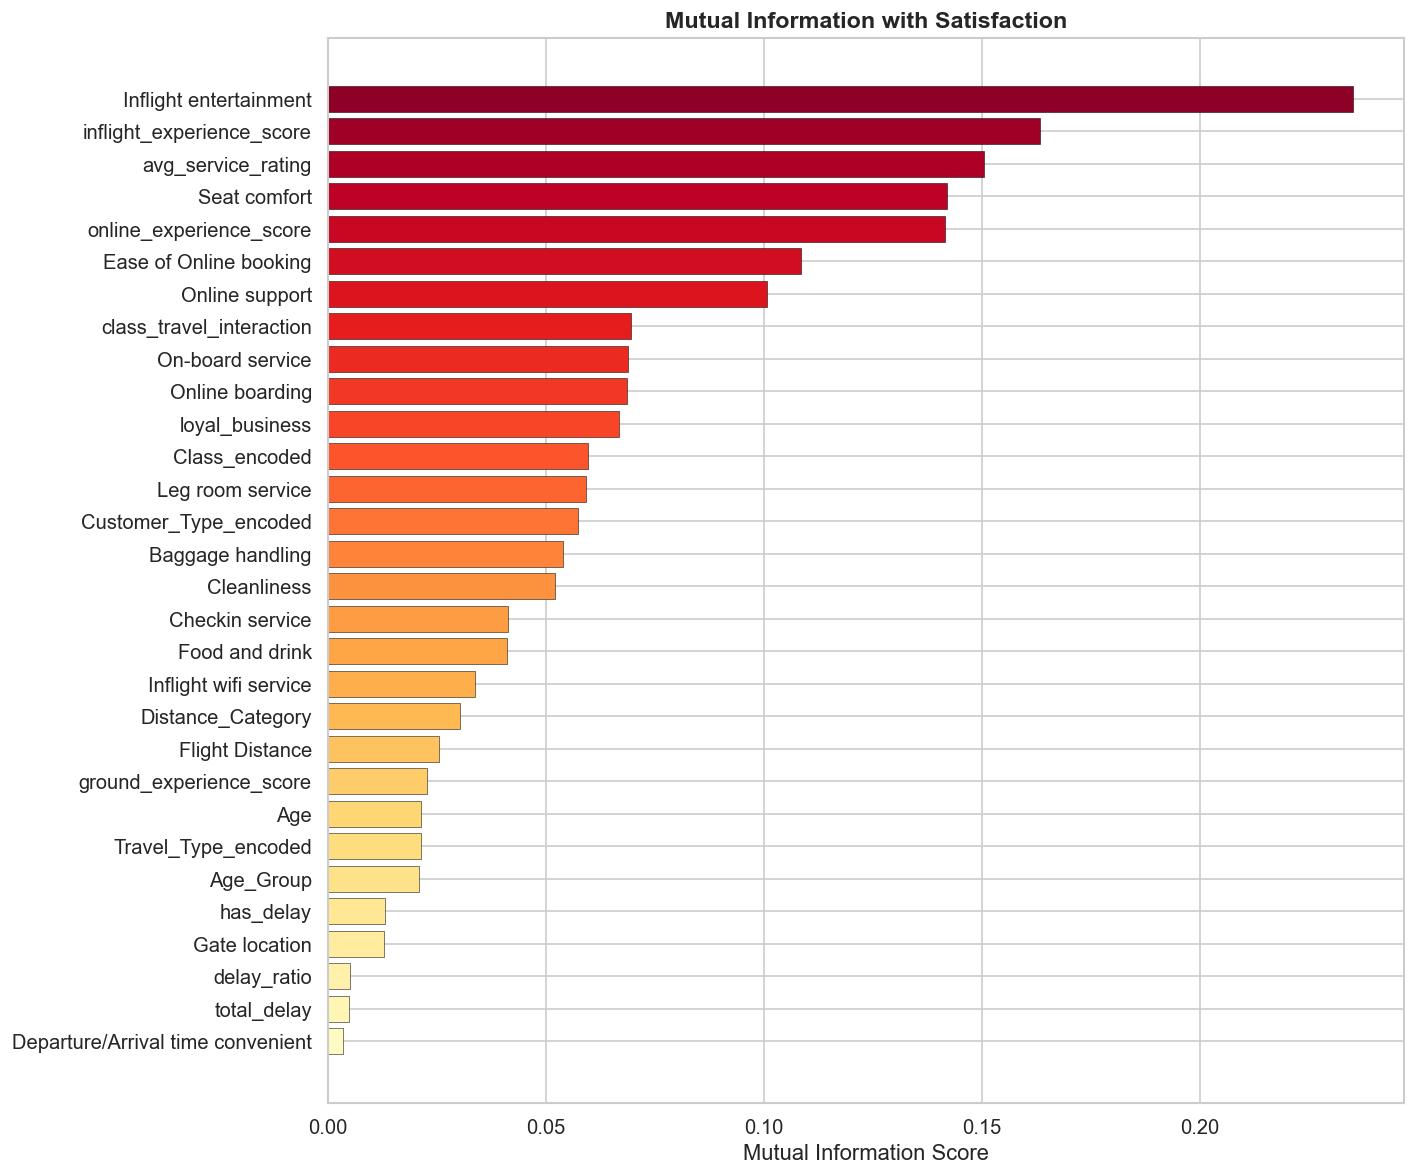

Top 10 features by Mutual Information:


,feature,mutual_info
5,Inflight entertainment,0.235122
21,inflight_experience_score,0.163249
19,avg_service_rating,0.150505
0,Seat comfort,0.142070
20,online_experience_score,0.141547
7,Ease of Online booking,0.108505
6,Online support,0.100815
28,class_travel_interaction,0.069522
8,On-board service,0.068948
13,Online boarding,0.068600


In [22]:
mi = mutual_info_classif(df[feature_cols], df['satisfaction_label'], random_state=42)
mi_df = pd.DataFrame({'feature': feature_cols, 'mutual_info': mi}).sort_values('mutual_info', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
colors = sns.color_palette('YlOrRd_r', n_colors=len(mi_df))
ax.barh(mi_df['feature'][::-1], mi_df['mutual_info'][::-1], color=colors[::-1],
        edgecolor='black', linewidth=0.3)
ax.set_title('Mutual Information with Satisfaction', fontsize=14, fontweight='bold')
ax.set_xlabel('Mutual Information Score')

plt.tight_layout()
plt.show()

print('Top 10 features by Mutual Information:')
mi_df.head(10)

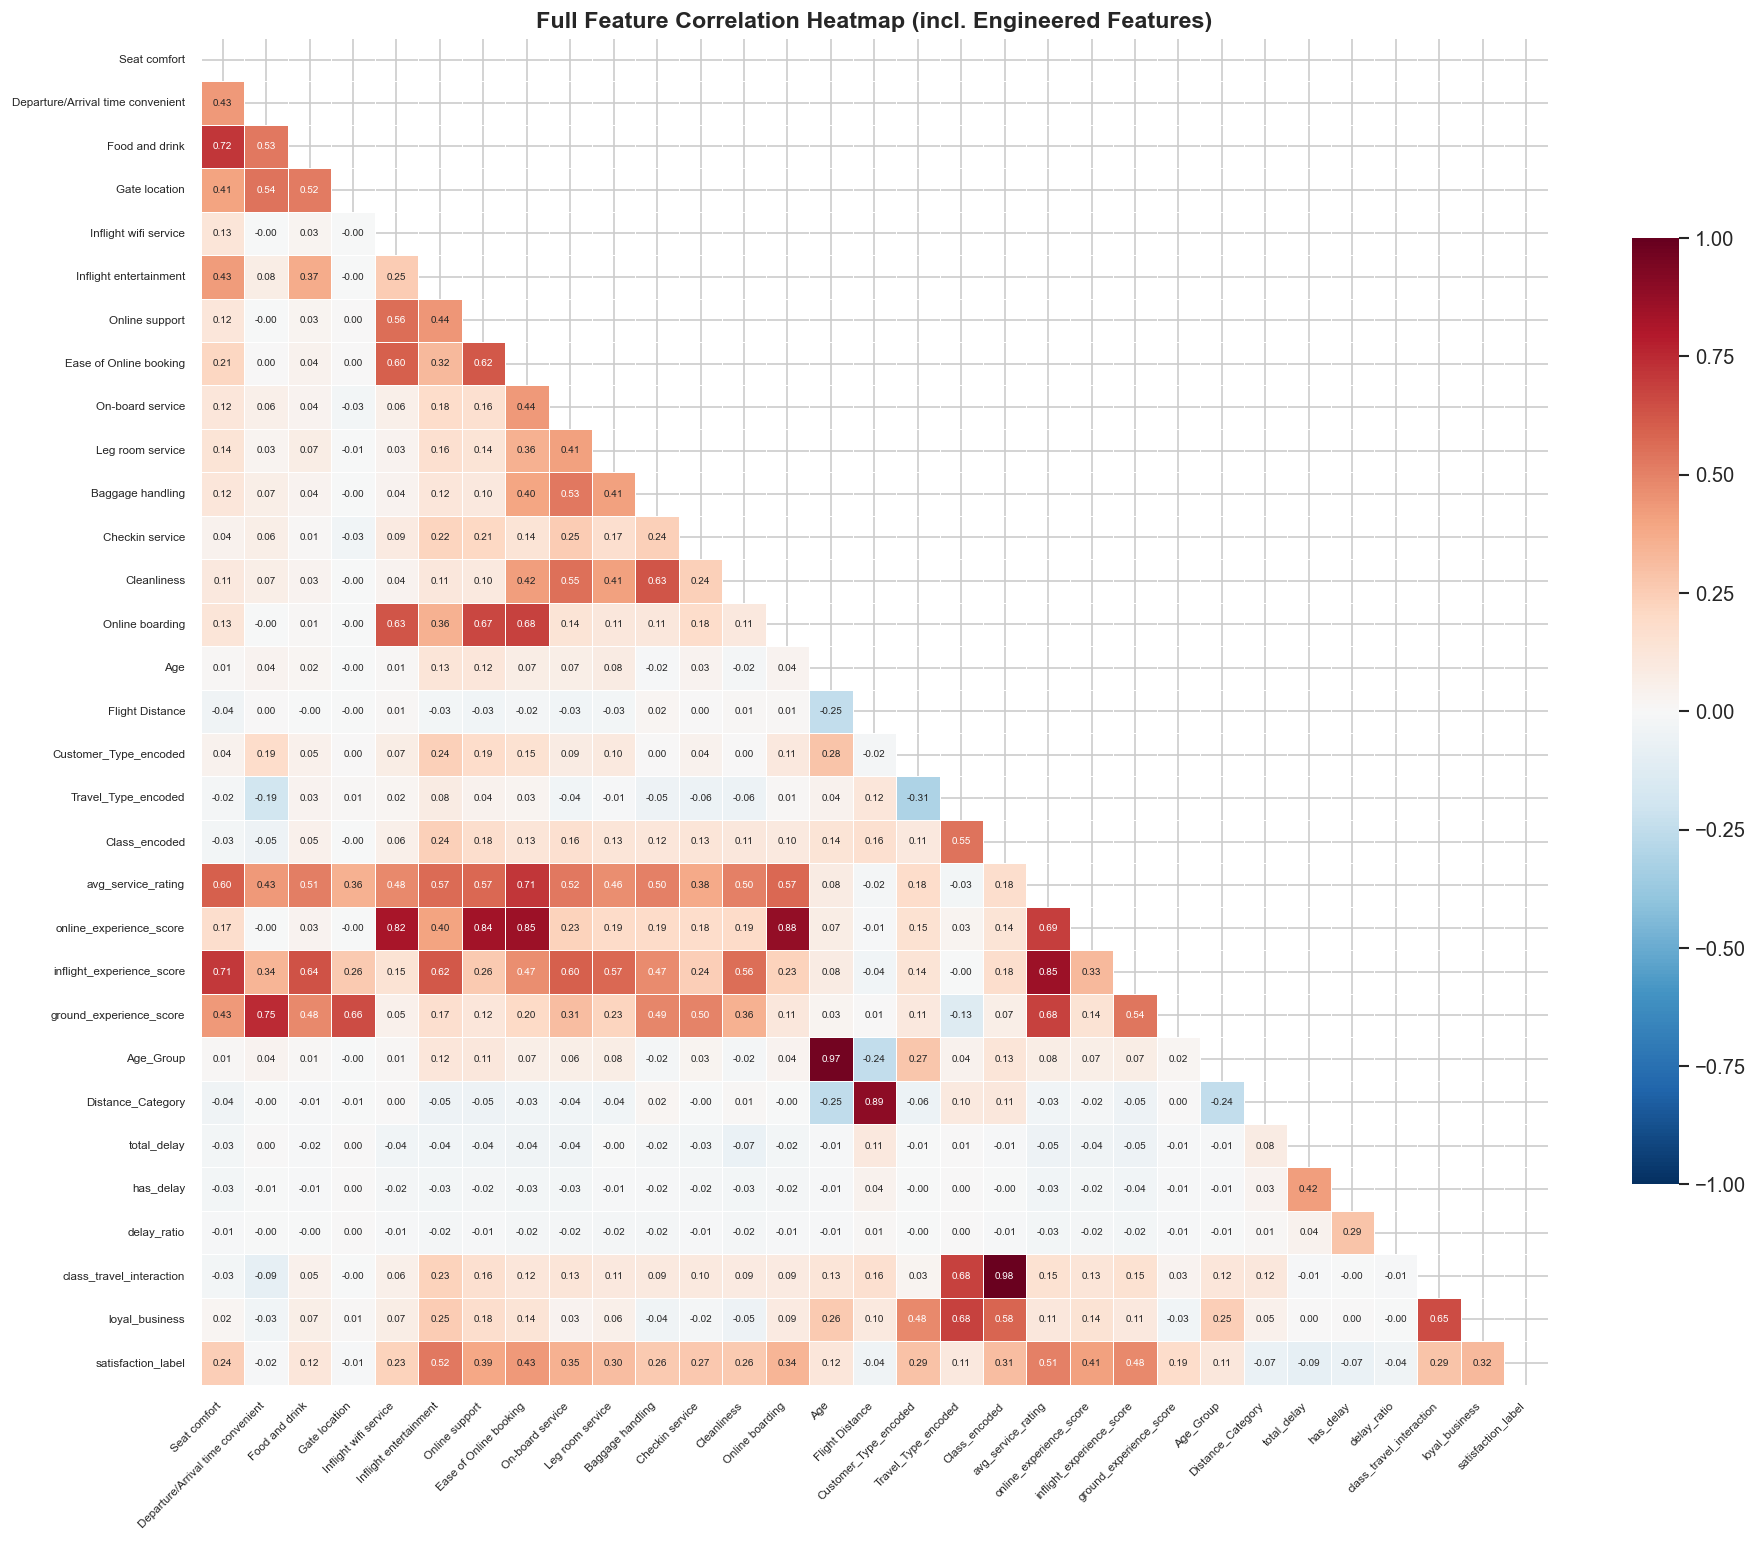

In [23]:
fig, ax = plt.subplots(figsize=(16, 13))
corr_matrix = df_scaled[feature_cols + ['satisfaction_label']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.3, linecolor='white',
            cbar_kws={'shrink': 0.7},
            annot_kws={'size': 6}, ax=ax)
ax.set_title('Full Feature Correlation Heatmap (incl. Engineered Features)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

## 8. Train / Test Split
Stratified 80/20 split preserving target class balance.

In [24]:
FINAL_FEATURES = feature_cols.copy()

X = df_scaled[FINAL_FEATURES]
y = df_scaled['satisfaction_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'Features:     {X_train.shape[1]}')

Training set: 103,904 samples (80.0%)
Test set:     25,976 samples (20.0%)
Features:     30


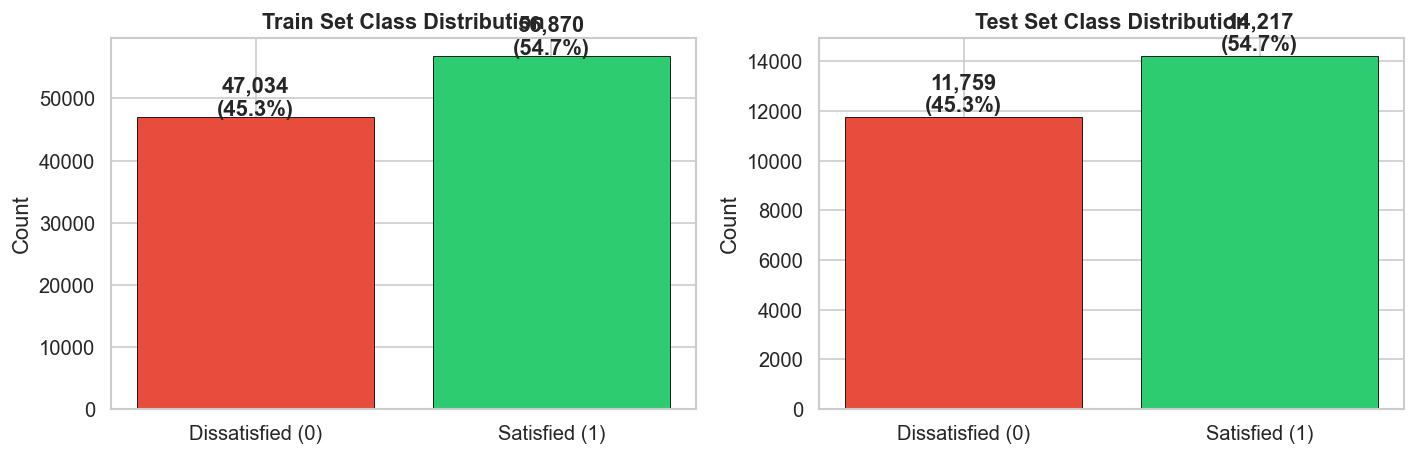

Satisfied ratio -- Train: 0.5473, Test: 0.5473
Difference: 0.0000 (should be < 0.005)


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, data) in zip(axes, [('Train', y_train), ('Test', y_test)]):
    vc = data.value_counts().sort_index()
    bars = ax.bar(['Dissatisfied (0)', 'Satisfied (1)'], vc.values,
                  color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
                f'{val:,}\n({val/len(data)*100:.1f}%)', ha='center', fontweight='bold')
    ax.set_title(f'{name} Set Class Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

train_ratio = y_train.mean()
test_ratio = y_test.mean()
print(f'Satisfied ratio -- Train: {train_ratio:.4f}, Test: {test_ratio:.4f}')
print(f'Difference: {abs(train_ratio - test_ratio):.4f} (should be < 0.005)')

## 9. Export Prepared Data
Save all prepared datasets and metadata for downstream use.

In [26]:
prepared_full = df_scaled[FINAL_FEATURES + ['satisfaction_label']].copy()
prepared_full.to_csv('prepared_data.csv', index=False)
print(f'Saved prepared_data.csv: {prepared_full.shape}')

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print(f'Saved X_train.csv: {X_train.shape}')
print(f'Saved X_test.csv: {X_test.shape}')
print(f'Saved y_train.csv: {y_train.shape}')
print(f'Saved y_test.csv: {y_test.shape}')

Saved prepared_data.csv: (129880, 31)
Saved X_train.csv: (103904, 30)
Saved X_test.csv: (25976, 30)
Saved y_train.csv: (103904,)
Saved y_test.csv: (25976,)


In [27]:
feature_metadata = {
    'total_features': len(FINAL_FEATURES),
    'original_columns': 22,
    'engineered_features': len(FINAL_FEATURES) - len(SERVICE_COLS) - 2,
    'feature_list': FINAL_FEATURES,
    'target': 'satisfaction_label',
    'encoding_map': {
        'Customer_Type_encoded': {'disloyal Customer': 0, 'Loyal Customer': 1},
        'Travel_Type_encoded': {'Personal Travel': 0, 'Business travel': 1},
        'Class_encoded': {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
    },
    'scaling': {
        'standard_scaler': continuous_to_scale,
        'minmax_scaler': SERVICE_COLS
    },
    'train_test_split': {
        'test_size': 0.2,
        'random_state': 42,
        'stratified': True,
        'train_samples': int(X_train.shape[0]),
        'test_samples': int(X_test.shape[0])
    }
}

with open('feature_metadata.json', 'w') as f:
    json.dump(feature_metadata, f, indent=2)

print('Saved feature_metadata.json')
print(f"\nTotal features: {feature_metadata['total_features']}")
print(f"Engineered features: {feature_metadata['engineered_features']}")

Saved feature_metadata.json

Total features: 30
Engineered features: 14


## 10. Data Preparation Report

### Data Dictionary

| # | Feature | Type | Source | Transformation |
|---|---------|------|--------|----------------|
| 1-14 | Service ratings (14 cols) | float | Original | Min-Max scaled to [0,1] |
| 15 | Age | float | Original | Z-score standardized |
| 16 | Flight Distance | float | Original | Z-score standardized |
| 17 | Customer_Type_encoded | int | Customer Type | Binary: Loyal=1, disloyal=0 |
| 18 | Travel_Type_encoded | int | Type of Travel | Binary: Business=1, Personal=0 |
| 19 | Class_encoded | int | Class | Ordinal: Eco=0, Eco Plus=1, Business=2 |
| 20 | avg_service_rating | float | Engineered | Mean of 14 service ratings |
| 21 | online_experience_score | float | Engineered | Mean of online-related ratings |
| 22 | inflight_experience_score | float | Engineered | Mean of inflight-related ratings |
| 23 | ground_experience_score | float | Engineered | Mean of ground-related ratings |
| 24 | Age_Group | int | Engineered | Bins: 0=<18, 1=18-30, 2=31-45, 3=46-60, 4=60+ |
| 25 | Distance_Category | int | Engineered | Bins: 0=Short, 1=Medium, 2=Long |
| 26 | total_delay | float | Engineered | Sum of departure + arrival delay (Z-scaled) |
| 27 | has_delay | int | Engineered | Binary: 1 if any delay > 0 |
| 28 | delay_ratio | float | Engineered | Arrival / (Departure + 1) (Z-scaled) |
| 29 | class_travel_interaction | int | Engineered | Class x Travel Type (6 categories, 0-5) |
| 30 | loyal_business | int | Engineered | Loyal Customer AND Business Travel |

### Summary of Changes
- **Original**: 22 columns -> **Final**: 30 features + 1 target
- **Nulls**: 393 in Arrival Delay -> imputed with median (0.0)
- **Outliers**: Delays capped at 99th percentile
- **Encoding**: 3 categorical -> 3 numeric (binary/ordinal)
- **Scaling**: 4 continuous features standardized (Z-score), 14 service ratings normalized (Min-Max)
- **Engineered**: 11 new features (composites, bins, delay transforms, interactions)

### Modeling Recommendations
- **Tree-based models** (Random Forest, XGBoost): will benefit from interaction and binned features
- **Linear/logistic models**: benefit from scaling and encoded categoricals
- **Class imbalance**: mild (~45/55) — use `class_weight='balanced'` or stratified CV
- **Top predictors to watch**: Online boarding, Inflight entertainment, Inflight wifi (from EDA)


In [28]:
print('=' * 60)
print('DATA PREPARATION COMPLETE')
print('=' * 60)
print(f"\nFinal feature matrix: {X.shape[0]:,} samples x {X.shape[1]} features")
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f"\nFiles exported:")
print(f'  - prepared_data.csv')
print(f'  - X_train.csv, X_test.csv, y_train.csv, y_test.csv')
print(f'  - feature_metadata.json')
print(f"\nReady for modeling and Feature Store setup.")

DATA PREPARATION COMPLETE

Final feature matrix: 129,880 samples x 30 features
Train: 103,904 | Test: 25,976

Files exported:
  - prepared_data.csv
  - X_train.csv, X_test.csv, y_train.csv, y_test.csv
  - feature_metadata.json

Ready for modeling and Feature Store setup.
